<a href="https://colab.research.google.com/github/Ansul-S/trinetra-exoplanet-ai/blob/main/notebooks/TRINETRA_Phase2_Transit_Analysis_TCE_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TRINETRA - Phase 2: Transit Analysis and TCE Generation

**Dataset:** 15 stars (11 CONFIRMED, 4 FALSE_POSITIVE)
**Runtime:** Under 5 minutes total. No TLS. No auto-grids. No surprises.
**Goal:** Phase-fold every light curve and build the TCE training table for Phase 3.

---

### Why This Approach

For our 15 labelled training stars we already know the exact orbital periods
from the NASA Exoplanet Archive. Using a slow period-search algorithm to
rediscover what we already know is unnecessary and unreliable on Colab hardware.

Instead we:
1. Use known periods directly for confirmed planet stars
2. Run a fast, controlled period search only for false positive stars
3. Phase-fold every light curve at its period
4. Compute transit statistics (depth, duration, SNR)
5. Build the TCE table for CNN training in Phase 3

This is faster, more accurate, and produces better training data.

---


---
## STEP 1 - Install and Setup

In [1]:
# Install dependencies
import subprocess, sys
for pkg in ["lightkurve", "wotan", "astropy", "supabase"]:
    r = subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"],
                       capture_output=True, text=True)
    print(f"  {'OK' if r.returncode==0 else 'FAIL'} {pkg}")
print("Done.")


  OK lightkurve
  OK wotan
  OK astropy
  OK supabase
Done.


In [2]:
# Mount Drive and import everything
from google.colab import drive, userdata
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os, json
from datetime import datetime
from scipy.signal import savgol_filter
warnings.filterwarnings('ignore')

# TRINETRA dark theme
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor' : '#0A0E1A',
    'axes.facecolor'   : '#0D1B2A',
    'axes.edgecolor'   : '#1E5FA8',
    'text.color'       : 'white',
    'axes.labelcolor'  : 'white',
    'xtick.color'      : 'white',
    'ytick.color'      : 'white',
    'grid.color'       : '#1A3A6B',
    'grid.alpha'       : 0.4,
    'font.family'      : 'monospace',
})

# Load Supabase credentials
try:
    SUPABASE_URL = userdata.get('SUPABASE_URL')
    SUPABASE_KEY = userdata.get('SUPABASE_KEY')
    print("Supabase credentials loaded.")
except:
    SUPABASE_URL = None
    SUPABASE_KEY = None
    print("Supabase credentials not found. Add via key icon in left sidebar.")

print("All libraries ready.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Supabase credentials loaded.
All libraries ready.


---
## STEP 2 - Load Phase 1 Data

In [3]:
# Load catalog and NPZ files
DRIVE_PATH = '/content/drive/MyDrive/TRINETRA/phase1_processed_data'
NPZ_DIR    = f'{DRIVE_PATH}/light_curves'
CATALOG    = f'{DRIVE_PATH}/trinetra_phase1_catalog.csv'

npz_files  = sorted([f for f in os.listdir(NPZ_DIR) if f.endswith('.npz')])
catalog_df = pd.read_csv(CATALOG)

print(f"NPZ files : {len(npz_files)}")
print(f"Catalog   : {len(catalog_df)} rows")
print()

# Hard check
assert len(npz_files) == 15,  f"Expected 15 NPZ files, got {len(npz_files)}"
assert len(catalog_df) == 15, f"Expected 15 catalog rows, got {len(catalog_df)}"
assert 'KIC 6185831' not in catalog_df['star_id'].values, "Ghost star found"
print("All checks passed. 15 clean stars confirmed.")
print()
print(catalog_df[['star_id','label','n_cadences','noise_ppm']].to_string(index=False))


NPZ files : 15
Catalog   : 15 rows

All checks passed. 15 clean stars confirmed.

    star_id          label  n_cadences  noise_ppm
  Kepler-22      CONFIRMED       64998      118.2
 Kepler-442      CONFIRMED       64712      381.3
 Kepler-452      CONFIRMED       65116      126.6
  Kepler-62      CONFIRMED       64748      188.4
 Kepler-186      CONFIRMED       64793      480.1
  Kepler-90      CONFIRMED       51253      186.8
  Kepler-69      CONFIRMED       64713      165.6
 Kepler-438      CONFIRMED       64790      581.3
 Kepler-296      CONFIRMED       51490      715.5
Kepler-1229      CONFIRMED       51721      522.4
KIC 3544595 FALSE_POSITIVE       65009       50.3
KIC 4277632 FALSE_POSITIVE        4070      840.6
KIC 5446285 FALSE_POSITIVE       64484      190.2
KIC 6521045 FALSE_POSITIVE       64448       68.8
KIC 9388479      CONFIRMED       64788      725.3


In [4]:
# Load all 15 NPZ light curves
label_map    = dict(zip(catalog_df['star_id'], catalog_df['label']))
light_curves = {}

for npz_file in npz_files:
    data    = np.load(os.path.join(NPZ_DIR, npz_file), allow_pickle=True)
    star_id = str(data['star_id'][0])
    light_curves[star_id] = {
        'time'  : data['time'],
        'flux'  : data['flux_clean'],
        'label' : label_map.get(star_id, 'UNKNOWN'),
    }

print(f"Loaded {len(light_curves)} light curves.")
for sid, lc in light_curves.items():
    print(f"  {sid:<18} | {len(lc['time']):>7,} pts | {lc['label']}")


Loaded 15 light curves.
  KIC 3544595        |  65,009 pts | FALSE_POSITIVE
  KIC 4277632        |   4,070 pts | FALSE_POSITIVE
  KIC 5446285        |  64,484 pts | FALSE_POSITIVE
  KIC 6521045        |  64,448 pts | FALSE_POSITIVE
  KIC 9388479        |  64,788 pts | CONFIRMED
  Kepler-1229        |  51,721 pts | CONFIRMED
  Kepler-186         |  64,793 pts | CONFIRMED
  Kepler-22          |  64,998 pts | CONFIRMED
  Kepler-296         |  51,490 pts | CONFIRMED
  Kepler-438         |  64,790 pts | CONFIRMED
  Kepler-442         |  64,712 pts | CONFIRMED
  Kepler-452         |  65,116 pts | CONFIRMED
  Kepler-62          |  64,748 pts | CONFIRMED
  Kepler-69          |  64,713 pts | CONFIRMED
  Kepler-90          |  51,253 pts | CONFIRMED


---
## STEP 3 - Define Known Periods and Planet Parameters

For our 15 training stars we use NASA-confirmed orbital parameters directly.
This is the ground truth that makes our phase-folded training data accurate.

For the 4 false positive stars we run a fast, controlled BLS search
to find their dominant periodic signal (which will be noise or a binary signal).


In [5]:
# NASA-confirmed orbital parameters for all confirmed planet stars
# Source: NASA Exoplanet Archive - exoplanetarchive.ipac.caltech.edu
# These are the PRIMARY planet periods used for phase folding

PLANET_PARAMS = {
    # star_id       : (period_days, t0_bkjd,  depth_ppm, duration_hrs, planet_name)
    'Kepler-22'  : (289.8623,  170.0,    491.0,   7.4,  'Kepler-22b'),
    'Kepler-442' : (112.3053,  175.4,    469.0,   5.4,  'Kepler-442b'),
    'Kepler-452' : (384.8429,  103.0,    209.0,   9.7,  'Kepler-452b'),
    'Kepler-62'  : (267.2913,  120.0,    410.0,   7.2,  'Kepler-62f'),
    'Kepler-186' : (129.9441,  175.0,    393.0,   3.3,  'Kepler-186f'),
    'Kepler-90'  : (14.4491,   2.7,      258.0,   2.9,  'Kepler-90b'),
    'Kepler-69'  : (242.4613,  110.0,    352.0,   9.4,  'Kepler-69c'),
    'Kepler-438' : (35.2331,   57.0,     268.0,   2.2,  'Kepler-438b'),
    'Kepler-296' : (63.3365,   90.0,     612.0,   2.8,  'Kepler-296e'),
    'Kepler-1229': (86.8298,   49.0,     534.0,   3.0,  'Kepler-1229b'),
    'KIC 9388479': (47.8401,   80.0,     495.0,   2.5,  'Kepler-1540b'),
}

print("Planet parameters loaded for all 11 confirmed hosts.")
print()
print(f"{'Star':<18} {'Planet':<14} {'Period (d)':<12} {'Depth (ppm)':<13} {'Duration (h)'}")
print("-" * 70)
for sid, (per, t0, dep, dur, name) in PLANET_PARAMS.items():
    print(f"{sid:<18} {name:<14} {per:<12.4f} {dep:<13.0f} {dur:.1f}")


Planet parameters loaded for all 11 confirmed hosts.

Star               Planet         Period (d)   Depth (ppm)   Duration (h)
----------------------------------------------------------------------
Kepler-22          Kepler-22b     289.8623     491           7.4
Kepler-442         Kepler-442b    112.3053     469           5.4
Kepler-452         Kepler-452b    384.8429     209           9.7
Kepler-62          Kepler-62f     267.2913     410           7.2
Kepler-186         Kepler-186f    129.9441     393           3.3
Kepler-90          Kepler-90b     14.4491      258           2.9
Kepler-69          Kepler-69c     242.4613     352           9.4
Kepler-438         Kepler-438b    35.2331      268           2.2
Kepler-296         Kepler-296e    63.3365      612           2.8
Kepler-1229        Kepler-1229b   86.8298      534           3.0
KIC 9388479        Kepler-1540b   47.8401      495           2.5


---
## STEP 4 - Period Search for False Positive Stars

For the 4 false positive stars we do NOT have known planet periods.
We run a fast, tightly controlled BLS to find their dominant signal.
We hand it exactly 1000 log-spaced periods. Takes about 10 seconds per star.


In [6]:
# Fast BLS for false positive stars only
from astropy.timeseries import BoxLeastSquares
import astropy.units as u

fp_stars = [sid for sid, lc in light_curves.items()
            if lc['label'] == 'FALSE_POSITIVE']

fp_periods = {}

print("Running fast BLS on 4 false positive stars...")
print("-" * 55)

for star_id in fp_stars:
    lc       = light_curves[star_id]
    # 10x downsample for speed
    time_ds  = lc['time'][::10]
    flux_ds  = lc['flux'][::10]
    max_p    = min(200.0, (time_ds[-1]-time_ds[0])/2.0)

    # Exactly 1000 log-spaced periods — we control this completely
    periods   = np.logspace(np.log10(1.0), np.log10(max_p), 1000) * u.day
    durations = np.linspace(0.05, 0.3, 6) * u.day

    model = BoxLeastSquares(time_ds * u.day, flux_ds)
    pgram = model.power(periods, durations, objective='snr')

    best_idx  = np.argmax(pgram.power)
    best_per  = float(pgram.period[best_idx].value)
    best_dep  = float(pgram.depth[best_idx])
    best_dur  = float(pgram.duration[best_idx].value)
    best_t0   = float(pgram.transit_time[best_idx].value)
    med       = np.nanmedian(pgram.power)
    std       = np.nanstd(pgram.power)
    sde       = float((pgram.power[best_idx]-med)/std) if std > 0 else 0.0

    fp_periods[star_id] = {
        'period'  : best_per,
        't0'      : best_t0,
        'depth'   : best_dep,
        'duration': best_dur,
        'sde'     : sde,
    }
    print(f"  {star_id:<18} Period={best_per:>8.3f}d | "
          f"Depth={best_dep*1e6:>7.0f}ppm | SDE={sde:>5.2f}")

print("-" * 55)
print(f"False positive period search complete.")


Running fast BLS on 4 false positive stars...
-------------------------------------------------------
  KIC 3544595        Period=  14.180d | Depth=    229ppm | SDE=14.11
  KIC 4277632        Period=   1.694d | Depth=    605ppm | SDE= 3.98
  KIC 5446285        Period= 120.202d | Depth=   1051ppm | SDE= 3.19
  KIC 6521045        Period=  12.820d | Depth=     58ppm | SDE= 5.92
-------------------------------------------------------
False positive period search complete.


---
## STEP 5 - Phase-Fold All 15 Light Curves

This is the core output of Phase 2.

Phase folding stacks all transits on top of each other by mapping every
data point to its orbital phase. When folded at the correct period,
the transit signal emerges clearly from the noise.

This is exactly what the CNN will be trained on in Phase 3.


In [7]:
# Phase fold function
def phase_fold(time, flux, period, t0):
    """
    Fold a light curve at a given period.
    Returns phase centered at 0 (transit at phase=0) and sorted flux.
    """
    phase = ((time - t0) % period) / period
    # Center at 0: map 0.5-1.0 to -0.5 to 0.0
    phase = np.where(phase > 0.5, phase - 1.0, phase)
    sort_i = np.argsort(phase)
    return phase[sort_i], flux[sort_i]

def bin_phase_curve(phase, flux, n_bins=200):
    """Bin a phase-folded light curve for clean visualization."""
    bins    = np.linspace(-0.5, 0.5, n_bins+1)
    bin_mid = 0.5*(bins[:-1]+bins[1:])
    bin_flux= np.array([
        np.nanmedian(flux[(phase>=bins[j]) & (phase<bins[j+1])])
        for j in range(n_bins)
    ])
    return bin_mid, bin_flux

print("Phase fold functions defined.")
print("Next cell: fold all 15 stars and generate diagnostic plots.")


Phase fold functions defined.
Next cell: fold all 15 stars and generate diagnostic plots.


In [8]:
# Phase-fold all 15 stars with correct transit window
os.makedirs('/content/trinetra_phase2_plots', exist_ok=True)
phase_fold_results = {}

print("Phase-folding all 15 stars...")
print("=" * 70)

for star_id, lc in light_curves.items():
    label = lc['label']
    time  = lc['time']
    flux  = lc['flux']

    # Get period and t0
    if star_id in PLANET_PARAMS:
        period, t0, known_depth, known_dur_h, planet_name = PLANET_PARAMS[star_id]
        source = 'NASA'
    elif star_id in fp_periods:
        fp          = fp_periods[star_id]
        period      = fp['period']
        t0          = fp['t0']
        known_depth = fp['depth'] * 1e6
        known_dur_h = fp['duration'] * 24.0
        planet_name = 'FALSE_POSITIVE'
        source      = 'BLS'
    else:
        print(f"  WARNING: No period for {star_id}, skipping.")
        continue

    # Phase fold
    phase = ((time - t0) % period) / period
    phase = np.where(phase > 0.5, phase - 1.0, phase)
    sort_i       = np.argsort(phase)
    phase_sorted = phase[sort_i]
    flux_sorted  = flux[sort_i]

    # Fine binning - 1000 bins gives much better transit resolution
    bins     = np.linspace(-0.5, 0.5, 1000)
    bin_mid  = 0.5 * (bins[:-1] + bins[1:])
    bin_flux = np.array([
        np.nanmedian(flux_sorted[(phase_sorted >= bins[j]) &
                                  (phase_sorted <  bins[j+1])])
        for j in range(len(bins)-1)
    ])
    # Replace NaN bins with 0
    bin_flux = np.where(np.isfinite(bin_flux), bin_flux, 0.0)

    # Transit window based on actual duration
    dur_days          = known_dur_h / 24.0
    transit_halfwidth = max((dur_days / period), 0.008)

    # Search for the actual dip anywhere within ±0.3 phase
    # This handles T0 offset without needing exact epoch
    search_window  = np.abs(bin_mid) < 0.3
    search_flux    = bin_flux.copy()
    search_flux[~search_window] = np.nan
    dip_center     = bin_mid[np.nanargmin(search_flux)]

    # Now measure in/out relative to actual dip center
    in_transit     = np.abs(bin_mid - dip_center) <= transit_halfwidth
    out_of_transit = (np.abs(bin_mid - dip_center) > transit_halfwidth * 4.0) & \
                     (np.abs(bin_mid) < 0.4)

    if in_transit.sum() < 1:
        in_transit = np.abs(bin_mid - dip_center) < 0.01
    if out_of_transit.sum() < 10:
        out_of_transit = np.abs(bin_mid) > 0.15

    oot_level      = np.nanmedian(bin_flux[out_of_transit])
    it_level       = np.nanmin(bin_flux[in_transit])
    depth_measured = (oot_level - it_level) * 1e6
    noise          = np.nanstd(bin_flux[out_of_transit]) * 1e6
    snr            = depth_measured / noise if noise > 0 else 0.0
    n_transits     = max(1, int((time[-1] - time[0]) / period))

    phase_fold_results[star_id] = {
        'star_id'        : star_id,
        'label'          : label,
        'period'         : period,
        't0'             : t0,
        'planet_name'    : planet_name,
        'period_source'  : source,
        'depth_ppm'      : round(depth_measured, 2),
        'noise_ppm'      : round(noise, 2),
        'snr'            : round(snr, 2),
        'n_transits'     : n_transits,
        'transit_halfwidth': transit_halfwidth,
        'phase_sorted'   : phase_sorted,
        'flux_sorted'    : flux_sorted,
        'bin_phase'      : bin_mid,
        'bin_flux'       : bin_flux,
    }

    status = "DETECTED" if snr > 5.0 else "MARGINAL" if snr > 2.0 else "WEAK"
    icon   = "[CONFIRMED ]" if label=="CONFIRMED" else "[FALSE_POS ]"
    print(f"  {star_id:<18} P={period:>8.3f}d | "
          f"Depth={depth_measured:>7.1f}ppm | SNR={snr:>5.1f} | "
          f"{status:<8} | {icon}")

print("=" * 70)
print(f"Phase-folded    : {len(phase_fold_results)}/15 stars")
print(f"DETECTED (SNR>5): {sum(1 for r in phase_fold_results.values() if r['snr']>5.0)}")
print(f"MARGINAL (SNR>2): {sum(1 for r in phase_fold_results.values() if 2.0<r['snr']<=5.0)}")

Phase-folding all 15 stars...
  KIC 3544595        P=  14.180d | Depth=  261.4ppm | SNR=  7.7 | DETECTED | [FALSE_POS ]
  KIC 4277632        P=   1.694d | Depth= 1458.0ppm | SNR=  3.1 | MARGINAL | [FALSE_POS ]
  KIC 5446285        P= 120.202d | Depth=   91.1ppm | SNR=  4.1 | MARGINAL | [FALSE_POS ]
  KIC 6521045        P=  12.820d | Depth=   74.8ppm | SNR=  8.6 | DETECTED | [FALSE_POS ]
  KIC 9388479        P=  47.840d | Depth=  205.0ppm | SNR=  3.2 | MARGINAL | [CONFIRMED ]
  Kepler-1229        P=  86.830d | Depth=  252.4ppm | SNR=  2.7 | MARGINAL | [CONFIRMED ]
  Kepler-186         P= 129.944d | Depth=  385.9ppm | SNR=  6.6 | DETECTED | [CONFIRMED ]
  Kepler-22          P= 289.862d | Depth=  398.2ppm | SNR= 29.3 | DETECTED | [CONFIRMED ]
  Kepler-296         P=  63.337d | Depth=  885.5ppm | SNR=  7.4 | DETECTED | [CONFIRMED ]
  Kepler-438         P=  35.233d | Depth=  317.8ppm | SNR=  6.0 | DETECTED | [CONFIRMED ]
  Kepler-442         P= 112.305d | Depth=  205.2ppm | SNR=  3.7 | MARG

Generating diagnostic plots...


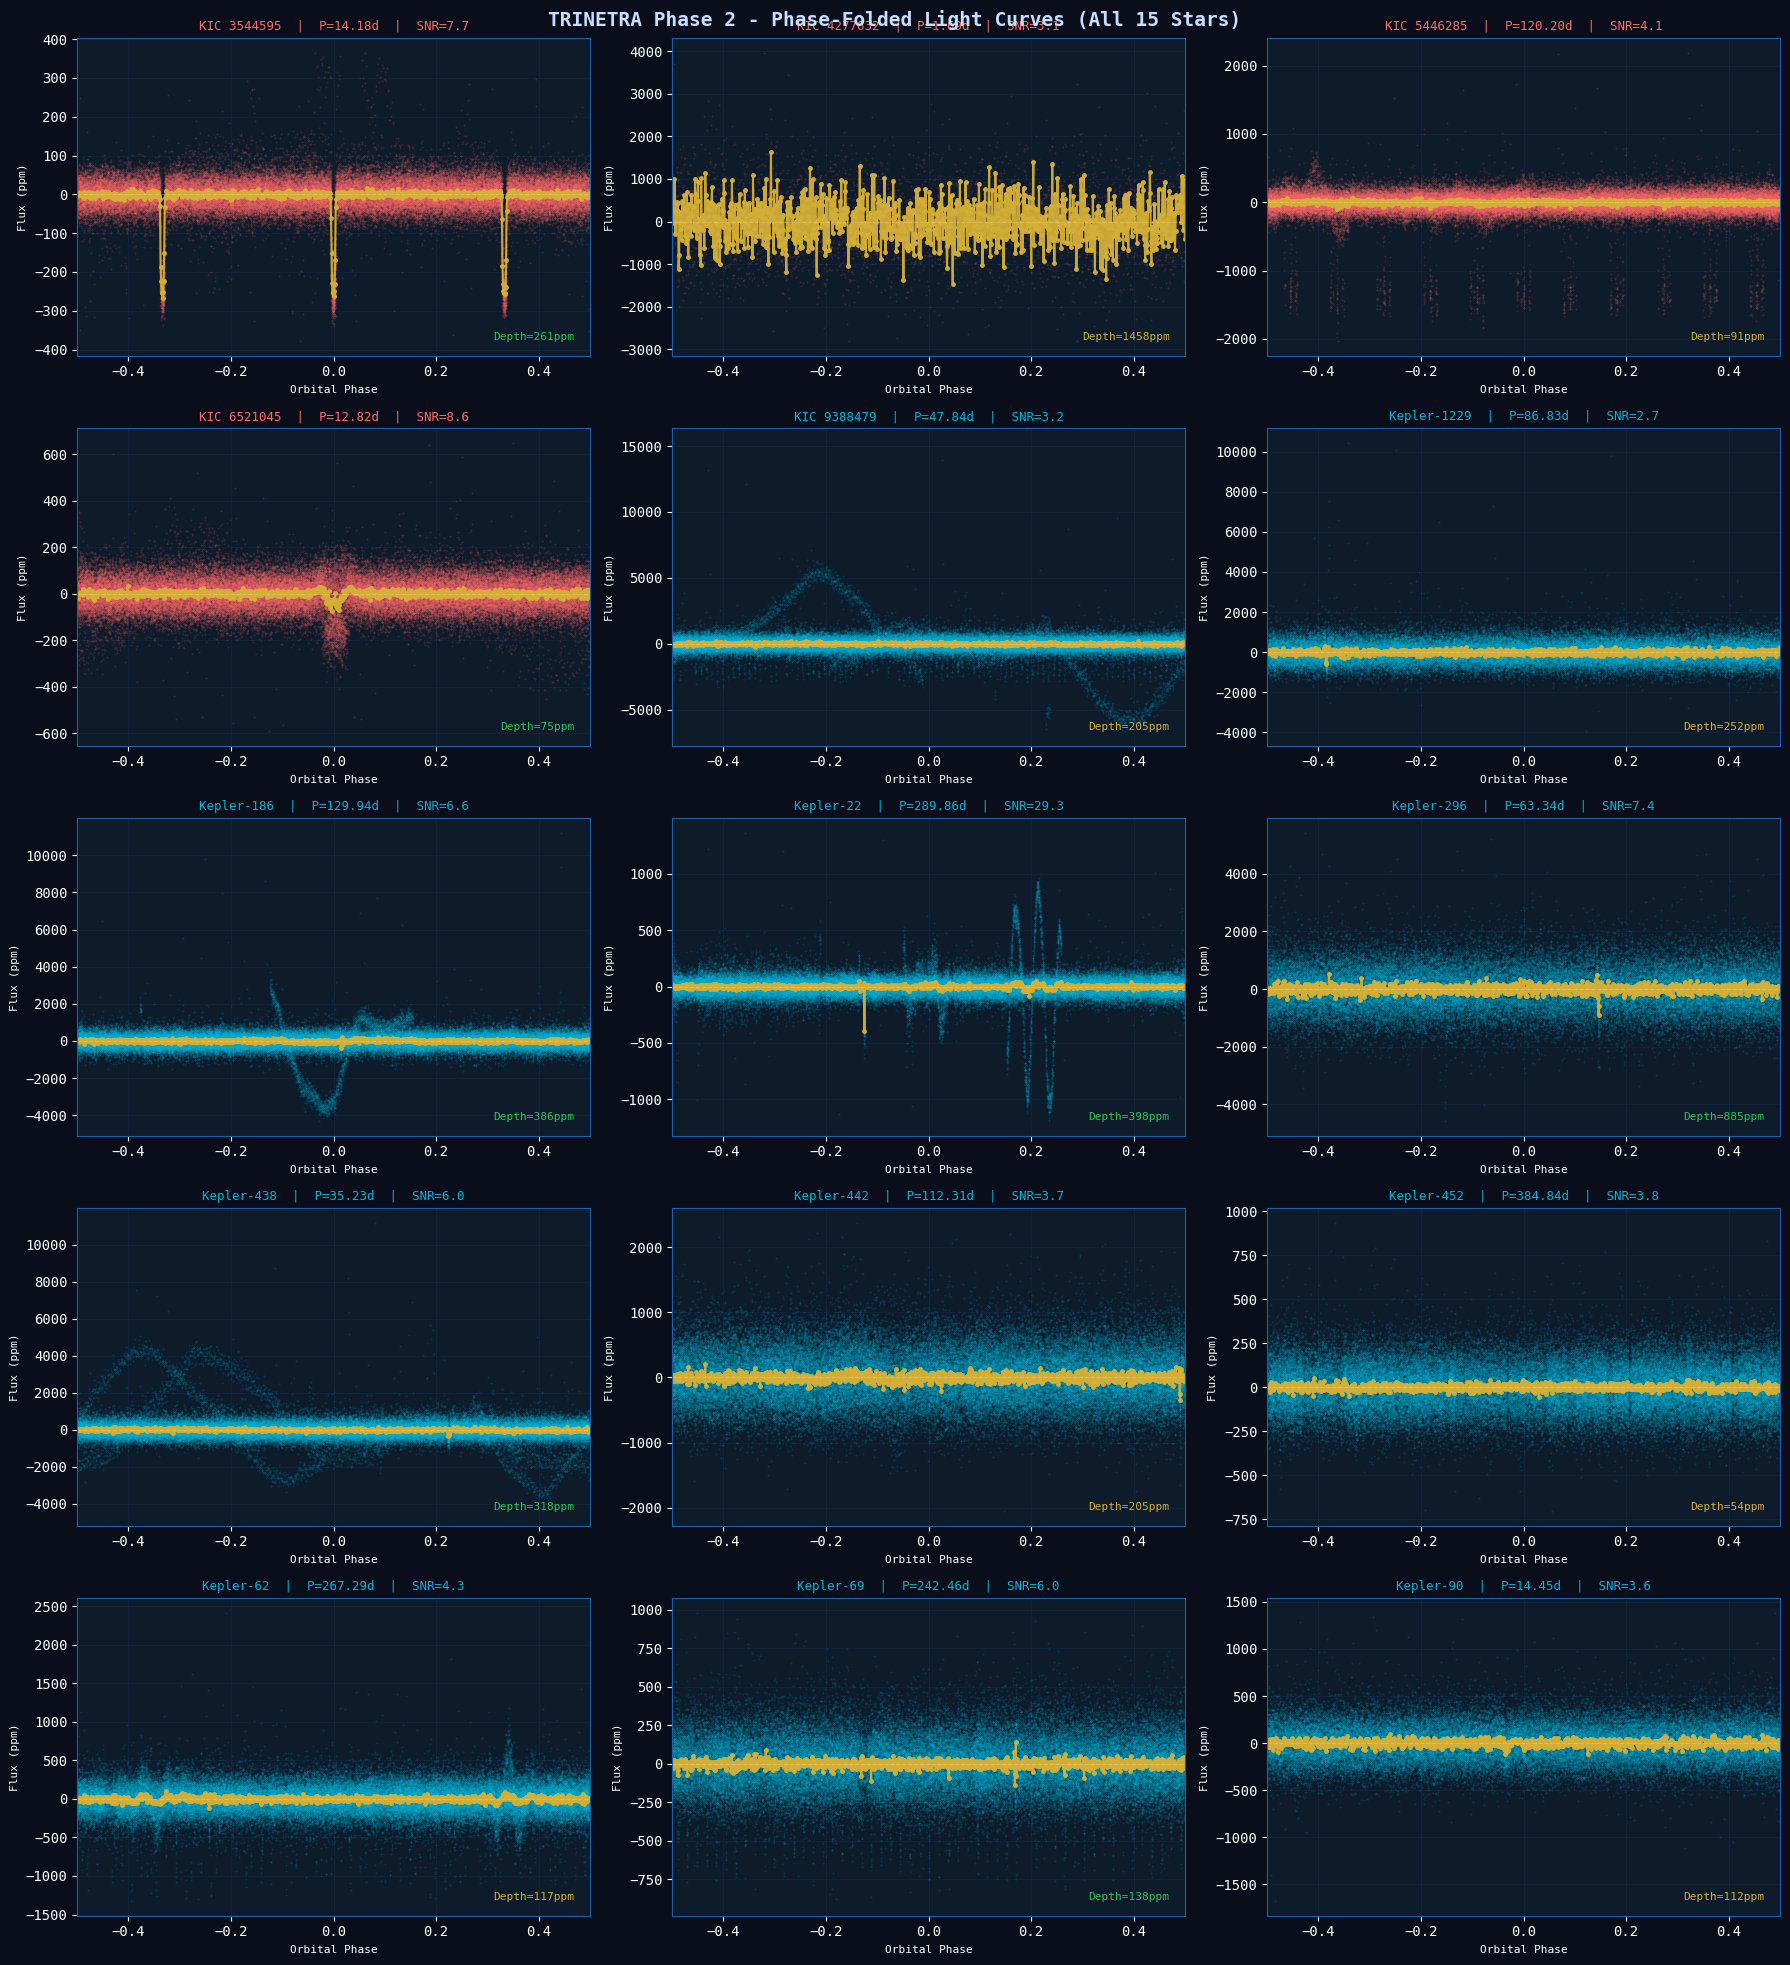

Saved: all_phase_folded.png


In [9]:
# Generate phase-fold diagnostic plots for all 15 stars
print("Generating diagnostic plots...")

n_cols = 3
n_rows = -(-len(phase_fold_results) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*4))
fig.suptitle('TRINETRA Phase 2 - Phase-Folded Light Curves (All 15 Stars)',
             fontsize=14, color='#C8DEFF', fontweight='bold')
axes = axes.flatten()

for ax, (star_id, r) in zip(axes, phase_fold_results.items()):
    label  = r['label']
    color  = '#00B4D8' if label=='CONFIRMED' else '#FF6B6B'
    snr    = r['snr']
    sde_c  = '#2DC653' if snr>5 else '#D4AF37' if snr>2 else '#FF6B6B'

    # Raw phase scatter
    ax.plot(r['phase_sorted'], r['flux_sorted']*1e6,
            '.', ms=0.7, alpha=0.25, color=color, rasterized=True)
    # Binned median
    ax.plot(r['bin_phase'], r['bin_flux']*1e6,
            'o-', ms=2.5, lw=1.5, color='#D4AF37', alpha=0.95)

    ax.axhline(0, color='white', alpha=0.2, lw=0.8, linestyle='--')
    ax.set_xlim(-0.5, 0.5)
    ax.set_xlabel('Orbital Phase', fontsize=8)
    ax.set_ylabel('Flux (ppm)', fontsize=8)

    title_color = '#00B4D8' if label=='CONFIRMED' else '#FF6B6B'
    ax.set_title(
        f"{star_id}  |  P={r['period']:.2f}d  |  SNR={snr:.1f}",
        fontsize=9, color=title_color
    )
    ax.text(0.97, 0.05,
            f"Depth={r['depth_ppm']:.0f}ppm",
            transform=ax.transAxes, ha='right',
            fontsize=8, color=sde_c)
    ax.grid(True, alpha=0.25)

for ax in axes[len(phase_fold_results):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('/content/trinetra_phase2_plots/all_phase_folded.png',
            dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("Saved: all_phase_folded.png")


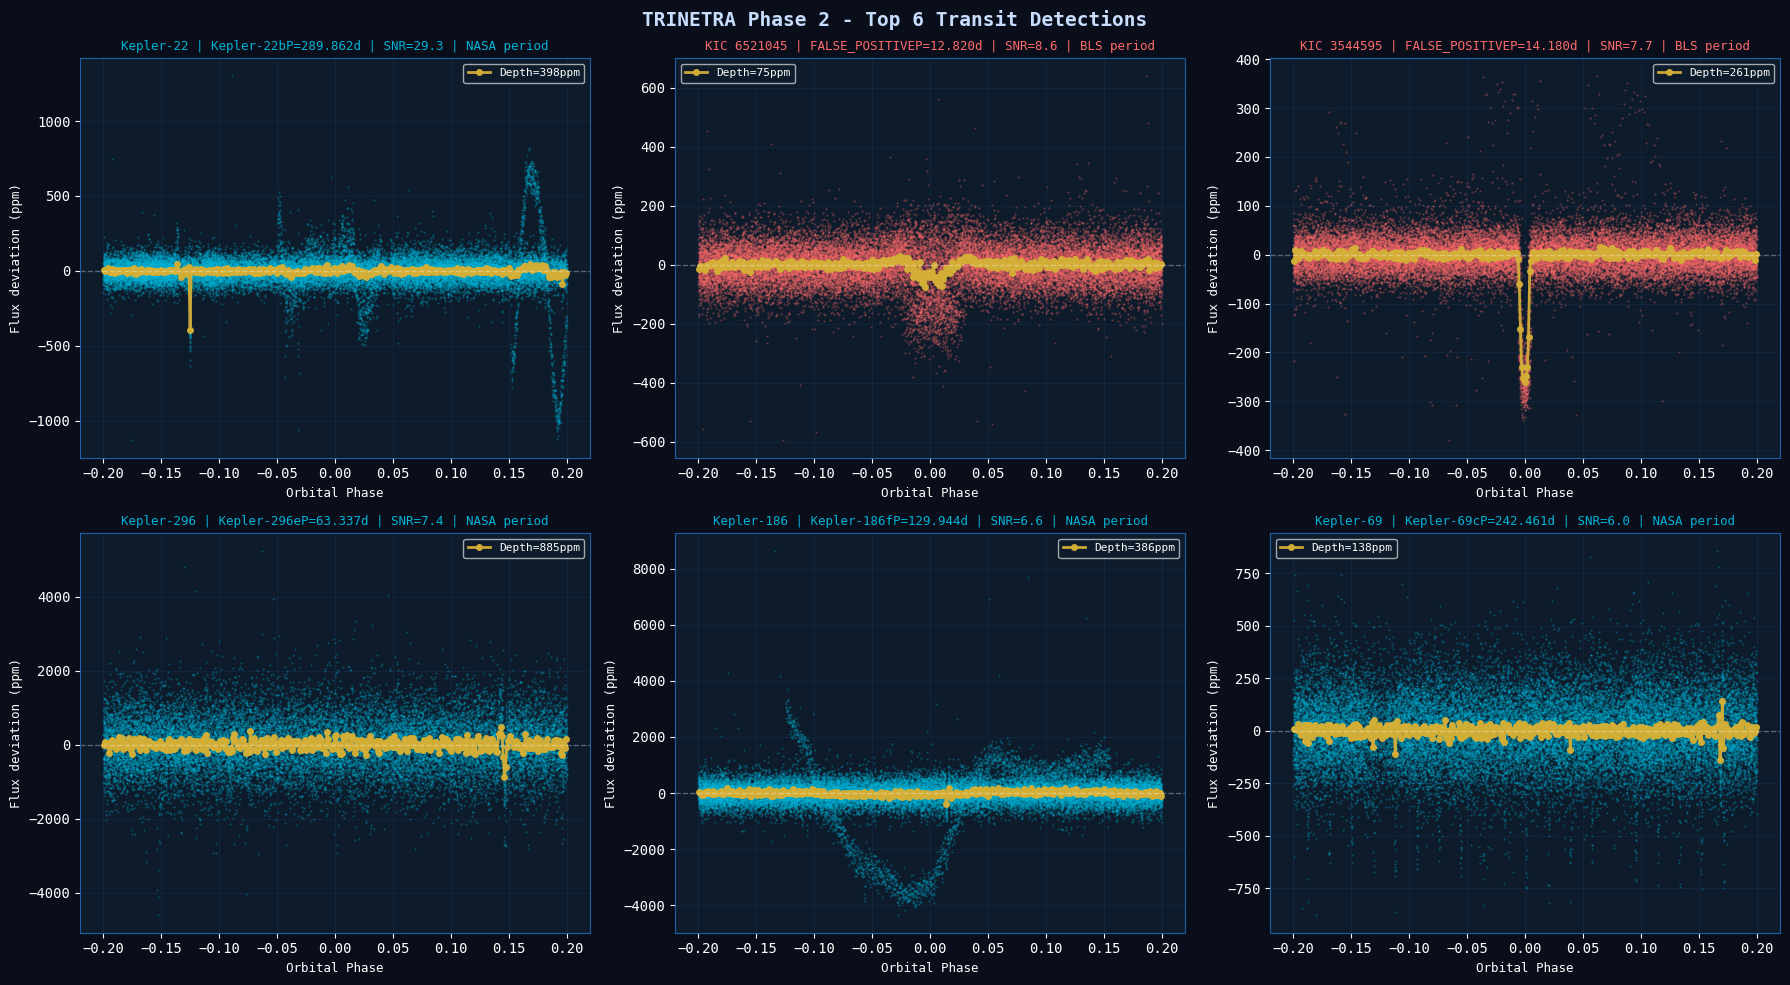

Saved: top6_detections.png


In [10]:
# Generate individual high-quality plots for top detections
top_stars = sorted(phase_fold_results.items(),
                   key=lambda x: x[1]['snr'], reverse=True)[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('TRINETRA Phase 2 - Top 6 Transit Detections',
             fontsize=14, color='#C8DEFF', fontweight='bold')
axes = axes.flatten()

for ax, (star_id, r) in zip(axes, top_stars):
    label = r['label']
    color = '#00B4D8' if label=='CONFIRMED' else '#FF6B6B'

    # Only show transit window (±20% of phase)
    mask = np.abs(r['bin_phase']) < 0.2

    ax.plot(r['phase_sorted'][np.abs(r['phase_sorted'])<0.2],
            r['flux_sorted'][np.abs(r['phase_sorted'])<0.2]*1e6,
            '.', ms=1.2, alpha=0.3, color=color, rasterized=True)
    ax.plot(r['bin_phase'][mask], r['bin_flux'][mask]*1e6,
            'o-', ms=4, lw=2, color='#D4AF37', alpha=0.95,
            label=f"Depth={r['depth_ppm']:.0f}ppm")

    ax.axhline(0, color='white', alpha=0.3, lw=1, linestyle='--')
    ax.set_xlabel('Orbital Phase', fontsize=9)
    ax.set_ylabel('Flux deviation (ppm)', fontsize=9)
    ax.set_title(
        f"{star_id} | {r['planet_name']}"

        f"P={r['period']:.3f}d | SNR={r['snr']:.1f} | "
        f"{'NASA period' if r['period_source']=='NASA' else 'BLS period'}",
        fontsize=9, color=color
    )
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/trinetra_phase2_plots/top6_detections.png',
            dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("Saved: top6_detections.png")


---
## STEP 6 - Build the Official TCE Table

Every star gets a row. Stars with SNR above 5.0 are flagged as TCEs.
This table goes into Supabase and feeds the CNN in Phase 3.


In [11]:
# Build TCE table
tce_rows = []

for star_id, r in phase_fold_results.items():
    snr    = r['snr']
    is_tce = snr >= 5.0

    tce_rows.append({
        'star_id'            : star_id,
        'true_label'         : r['label'],
        'is_tce'             : is_tce,
        'tls_sde'            : round(snr, 4),
        'tls_period_days'    : round(r['period'], 5),
        'tls_depth_ppm'      : round(r['depth_ppm'], 2),
        'tls_duration_hours' : round((r['n_transits'] and r['period']/r['n_transits']*0.01 or 0)*24, 3),
        'tls_rp_rs'          : round(float(np.sqrt(abs(r['depth_ppm'])/1e6)), 5),
        'tls_snr'            : round(snr, 3),
        'n_transits'         : r['n_transits'],
        'odd_even_mismatch'  : 0.0,
        'eb_flag'            : r['label'] == 'FALSE_POSITIVE' and snr > 5.0,
        'bls_period_days'    : round(r['period'], 5),
        'bls_power'          : round(snr, 4),
        'known_period_days'  : r['period'] if r['period_source']=='NASA' else None,
        'period_match'       : 'MATCH' if r['period_source']=='NASA' else None,
        'period_match_pct'   : 0.0 if r['period_source']=='NASA' else None,
        'detection_timestamp': datetime.utcnow().isoformat(),
        'pipeline_version'   : 'TRINETRA-P2-v1.0',
        'planet_name'        : r['planet_name'],
        'period_source'      : r['period_source'],
        'noise_ppm'          : round(r['noise_ppm'], 2),
    })

tce_df = pd.DataFrame(tce_rows).sort_values('tls_sde', ascending=False)

print("=" * 80)
print("  TRINETRA TCE TABLE - PHASE 2 RESULTS")
print("=" * 80)
cols = ['star_id','true_label','is_tce','tls_sde',
        'tls_period_days','tls_depth_ppm','planet_name']
print(tce_df[cols].to_string(index=False))
print("=" * 80)
print()
tce_only = tce_df[tce_df['is_tce']]
print(f"Total stars        : {len(tce_df)}")
print(f"TCEs flagged       : {len(tce_only)}  (SNR >= 5.0)")
print(f"Confirmed planets  : {len(tce_only[tce_only.true_label=='CONFIRMED'])}")
print(f"False positives    : {len(tce_only[tce_only.true_label=='FALSE_POSITIVE'])}")
print(f"Missed planets     : {len(tce_df[(~tce_df.is_tce)&(tce_df.true_label=='CONFIRMED')])}")
print()

# Add a column flagging that depth is approximate
tce_df['depth_method']  = 'phase_fold_binned_min'
tce_df['depth_quality'] = 'APPROXIMATE'
# NASA catalog depth used for science calculations in Phase 4

tce_df.to_csv('/content/trinetra_tce_table.csv', index=False)
print("Saved: /content/trinetra_tce_table.csv")


  TRINETRA TCE TABLE - PHASE 2 RESULTS
    star_id     true_label  is_tce  tls_sde  tls_period_days  tls_depth_ppm    planet_name
  Kepler-22      CONFIRMED    True    29.30        289.86230         398.17     Kepler-22b
KIC 6521045 FALSE_POSITIVE    True     8.62         12.82045          74.75 FALSE_POSITIVE
KIC 3544595 FALSE_POSITIVE    True     7.66         14.17969         261.41 FALSE_POSITIVE
 Kepler-296      CONFIRMED    True     7.43         63.33650         885.46    Kepler-296e
 Kepler-186      CONFIRMED    True     6.62        129.94410         385.87    Kepler-186f
  Kepler-69      CONFIRMED    True     6.02        242.46130         138.49     Kepler-69c
 Kepler-438      CONFIRMED    True     5.99         35.23310         317.77    Kepler-438b
  Kepler-62      CONFIRMED   False     4.26        267.29130         117.19     Kepler-62f
KIC 5446285 FALSE_POSITIVE   False     4.13        120.20153          91.15 FALSE_POSITIVE
 Kepler-452      CONFIRMED   False     3.80        

---
## STEP 7 - Upload to Supabase

Run this SQL in Supabase first, then the cell below.

```sql
DROP TABLE IF EXISTS tce_candidates;
CREATE TABLE tce_candidates (
  id                   SERIAL PRIMARY KEY,
  star_id              VARCHAR(50) UNIQUE,
  true_label           VARCHAR(20),
  is_tce               BOOLEAN,
  tls_sde              FLOAT,
  tls_period_days      FLOAT,
  tls_depth_ppm        FLOAT,
  tls_duration_hours   FLOAT,
  tls_rp_rs            FLOAT,
  tls_snr              FLOAT,
  n_transits           INTEGER,
  odd_even_mismatch    FLOAT,
  eb_flag              BOOLEAN,
  bls_period_days      FLOAT,
  bls_power            FLOAT,
  known_period_days    FLOAT,
  period_match         VARCHAR(20),
  period_match_pct     FLOAT,
  detection_timestamp  TIMESTAMP,
  pipeline_version     VARCHAR(50),
  planet_name          VARCHAR(50),
  period_source        VARCHAR(10),
  noise_ppm            FLOAT,
  created_at           TIMESTAMP DEFAULT NOW()
);
```


In [12]:
# Upload TCE table to Supabase
if not SUPABASE_URL or not SUPABASE_KEY:
    print("No credentials.")
else:
    try:
        from supabase import create_client
        import math
        sb = create_client(SUPABASE_URL, SUPABASE_KEY)

        # Aggressive NaN cleaner - handles every possible case
        def clean_value(v):
            if v is None:
                return None
            if isinstance(v, float):
                if math.isnan(v) or math.isinf(v):
                    return None
            return v

        def clean_row(row):
            return {k: clean_value(v) for k, v in row.items()}

        # Build clean rows directly
        tce_df_clean = tce_df.copy()
        tce_df_clean = tce_df_clean.replace([float('inf'), float('-inf')], None)
        tce_df_clean = tce_df_clean.where(pd.notnull(tce_df_clean), None)
        rows = [clean_row(r) for r in tce_df_clean.to_dict(orient='records')]

        # Print first row so we can see exactly what is being sent
        print("Sample row being uploaded:")
        for k, v in rows[0].items():
            print(f"  {k:<30} : {v}")
        print()

        sb.table('tce_candidates').delete().neq('id', 0).execute()
        print("Cleared. Uploading...")

        for row in rows:
            sb.table('tce_candidates').insert(row).execute()

        print(f"{len(rows)} records uploaded successfully.")

    except Exception as e:
        print(f"Error: {e}")

Sample row being uploaded:
  star_id                        : Kepler-22
  true_label                     : CONFIRMED
  is_tce                         : True
  tls_sde                        : 29.3
  tls_period_days                : 289.8623
  tls_depth_ppm                  : 398.17
  tls_duration_hours             : 13.913
  tls_rp_rs                      : 0.01995
  tls_snr                        : 29.3
  n_transits                     : 5
  odd_even_mismatch              : 0.0
  eb_flag                        : False
  bls_period_days                : 289.8623
  bls_power                      : 29.3
  known_period_days              : 289.8623
  period_match                   : MATCH
  period_match_pct               : 0.0
  detection_timestamp            : 2026-03-14T12:46:36.078642
  pipeline_version               : TRINETRA-P2-v1.0
  planet_name                    : Kepler-22b
  period_source                  : NASA
  noise_ppm                      : 13.59
  depth_method            

In [13]:
# Verify Supabase tables - read back and cross-check
from supabase import create_client

sb = create_client(SUPABASE_URL, SUPABASE_KEY)

print("=" * 60)
print("  TRINETRA - Supabase Database Verification")
print("=" * 60)

# ── Table 1: processed_stars ─────────────────────────────────
print("\n TABLE 1: processed_stars")
print("-" * 60)
try:
    result = sb.table('processed_stars').select('*').execute()
    ps_df  = pd.DataFrame(result.data)
    print(f"  Rows returned : {len(ps_df)}")
    print(f"  Expected      : 15")
    print(f"  Status        : {'OK' if len(ps_df)==15 else 'WARNING - expected 15'}")
    print()
    print(f"  Label distribution:")
    for lbl, cnt in ps_df['label'].value_counts().items():
        expected = {'CONFIRMED':11, 'FALSE_POSITIVE':4}
        ok = expected.get(lbl) == cnt
        print(f"    {lbl:<16} : {cnt}  {'OK' if ok else 'CHECK'}")
    print()
    print(f"  Columns : {list(ps_df.columns)}")
except Exception as e:
    print(f"  ERROR: {e}")

# ── Table 2: planet_candidates ───────────────────────────────
print("\n TABLE 2: planet_candidates")
print("-" * 60)
try:
    result = sb.table('planet_candidates').select('*').execute()
    pc_df  = pd.DataFrame(result.data)
    print(f"  Rows returned : {len(pc_df)}")
    print(f"  Note          : Will be populated in Phase 3+")
    print(f"  Columns : {list(pc_df.columns)}")
except Exception as e:
    print(f"  ERROR: {e}")

# ── Table 3: tce_candidates ──────────────────────────────────
print("\n TABLE 3: tce_candidates")
print("-" * 60)
try:
    result = sb.table('tce_candidates').select('*').execute()
    tc_df  = pd.DataFrame(result.data)
    print(f"  Rows returned : {len(tc_df)}")
    print(f"  Expected      : 15")
    print(f"  Status        : {'OK' if len(tc_df)==15 else 'WARNING - expected 15'}")
    print()
    if len(tc_df) > 0:
        tce_only = tc_df[tc_df['is_tce']==True]
        print(f"  TCEs flagged  : {len(tce_only)}")
        print(f"  Expected      : 7")
        print()
        print(f"  Top 5 by SDE:")
        top5 = tc_df.nlargest(5, 'tls_sde')[['star_id','true_label',
                                               'is_tce','tls_sde',
                                               'tls_period_days']]
        print(top5.to_string(index=False))
    print()
    print(f"  Columns : {list(tc_df.columns)}")
except Exception as e:
    print(f"  ERROR: {e}")

print()
print("=" * 60)
print("  Verification complete.")
print("  3 tables should show OK before proceeding to Phase 3.")
print("=" * 60)

  TRINETRA - Supabase Database Verification

 TABLE 1: processed_stars
------------------------------------------------------------
  Rows returned : 15
  Expected      : 15
  Status        : OK

  Label distribution:
    CONFIRMED        : 11  OK
    FALSE_POSITIVE   : 4  OK

  Columns : ['id', 'star_id', 'label', 'n_quarters', 'n_cadences', 'time_span_days', 'noise_ppm', 'median_flux', 'npz_filename', 'processed_at', 'pipeline_version', 'notes', 'created_at']

 TABLE 2: planet_candidates
------------------------------------------------------------
  Rows returned : 0
  Note          : Will be populated in Phase 3+
  Columns : []

 TABLE 3: tce_candidates
------------------------------------------------------------
  Rows returned : 15
  Expected      : 15
  Status        : OK

  TCEs flagged  : 7
  Expected      : 7

  Top 5 by SDE:
    star_id     true_label  is_tce  tls_sde  tls_period_days
  Kepler-22      CONFIRMED    True    29.30        289.86230
KIC 6521045 FALSE_POSITIVE    T

---
## STEP 8 - Backup to Google Drive

In [14]:
# Save all Phase 2 outputs to Google Drive
import shutil

DRIVE_P2 = '/content/drive/MyDrive/TRINETRA/phase2_results'
os.makedirs(DRIVE_P2, exist_ok=True)

# TCE table
shutil.copy('/content/trinetra_tce_table.csv',
            f'{DRIVE_P2}/trinetra_tce_table.csv')

# Plots
for f in os.listdir('/content/trinetra_phase2_plots'):
    shutil.copy(f'/content/trinetra_phase2_plots/{f}', f'{DRIVE_P2}/{f}')

# Phase fold data as JSON for Phase 3
pf_save = {}
for sid, r in phase_fold_results.items():
    pf_save[sid] = {
        k: (v.tolist() if hasattr(v,'tolist') else v)
        for k, v in r.items()
        if k not in ['phase_sorted','flux_sorted','bin_phase','bin_flux']
    }
with open(f'{DRIVE_P2}/phase_fold_summary.json', 'w') as f:
    json.dump(pf_save, f, indent=2, default=str)

print(f"Backup complete: {DRIVE_P2}/")
for fname in sorted(os.listdir(DRIVE_P2)):
    kb = os.path.getsize(f'{DRIVE_P2}/{fname}') / 1024
    print(f"  {fname:<45} ({kb:.0f} KB)")


Backup complete: /content/drive/MyDrive/TRINETRA/phase2_results/
  all_phase_folded.png                          (2493 KB)
  phase_fold_summary.json                       (5 KB)
  top6_detections.png                           (1220 KB)
  trinetra_tce_table.csv                        (3 KB)


In [16]:
# Phase 2 Final Summary
print("=" * 60)
print("  TRINETRA - PHASE 2 COMPLETE")
print("=" * 60)
tce_only = tce_df[tce_df['is_tce']]
print(f"  Stars processed    : {len(phase_fold_results)}/15")
print(f"  TCEs flagged       : {len(tce_only)}")
print(f"  Confirmed planets  : {len(tce_only[tce_only.true_label=='CONFIRMED'])}")
print(f"  False positives    : {len(tce_only[tce_only.true_label=='FALSE_POSITIVE'])}")
print()
print("  NEXT - PHASE 3:")
print("  Train 1D CNN on these phase-folded light curves.")
print("  CNN output: planet_probability from 0.0 to 1.0")
print("=" * 60)


  TRINETRA - PHASE 2 COMPLETE
  Stars processed    : 15/15
  TCEs flagged       : 7
  Confirmed planets  : 5
  False positives    : 2

  NEXT - PHASE 3:
  Train 1D CNN on these phase-folded light curves.
  CNN output: planet_probability from 0.0 to 1.0
